# Quickstart: ECCC HRDPS forecast - dynamical.org Icechunk Zarr

HRDPS is the High Resolution Deterministic Prediction System, Environment and Climate Change Canada's convection-permitting model. The continental domain covers Canada at 2.5 km resolution, with a new forecast every 6 hours, and an hourly forecast step out to 48 hours.

Dataset documentation: https://dynamical.org/catalog/eccc-hrdps-forecast/

Dataset licenced [CC-BY-4.0](https://creativecommons.org/licenses/by/4.0/). Processed by dynamical.org from ECCC data under the [ECCC Data Servers End-use Licence 2.1](https://eccc-msc.github.io/open-data/licence/readme_en/).

In [ ]:
# If running locally, follow README.md for simple dependency installation.
# If using Google Colab, run this cell.
!uv pip install dynamical-catalog cartopy

In [1]:
import icechunk
import xarray as xr

# Not in the STAC catalog yet. Once it is, this whole cell becomes:
#     import dynamical_catalog
#
#     ds = dynamical_catalog.open("eccc-hrdps-forecast", chunks=None)
#     ds
storage = icechunk.s3_storage(
    bucket="dynamical-eccc-hrdps",
    prefix="eccc-hrdps-forecast/v0.1.0.icechunk",
    region="us-west-2",
    anonymous=True,
)
ds = xr.open_zarr(icechunk.Repository.open(storage).readonly_session("main").store, chunks=None)
ds

<xarray.Dataset> Size: 2TB
Dimensions:                                        (init_time: 215,
                                                    lead_time: 49, y: 1290,
                                                    x: 2540)
Coordinates:
  * init_time                                      (init_time) datetime64[ns] 2kB ...
    expected_forecast_length                       (init_time) timedelta64[s] 2kB ...
    ingested_forecast_length                       (init_time) timedelta64[us] 2kB ...
  * lead_time                                      (lead_time) timedelta64[us] 392B ...
    valid_time                                     (init_time, lead_time) datetime64[ns] 84kB ...
  * y                                              (y) float64 10kB 16.7 ... ...
  * x                                              (x) float64 20kB -14.82 .....
    longitude                                      (y, x) float32 13MB ...
    latitude                                       (y, x) float32 13MB ...
    spatial_ref                                    int64 8B ...
Data variables: (12/17)
    categorical_precipitation_type_surface         (init_time, lead_time, y, x) float32 138GB ...
    downward_long_wave_radiation_flux_surface      (init_time, lead_time, y, x) float32 138GB ...
    convective_available_potential_energy_surface  (init_time, lead_time, y, x) float32 138GB ...
    dew_point_temperature_2m                       (init_time, lead_time, y, x) float32 138GB ...
    pressure_surface                               (init_time, lead_time, y, x) float32 138GB ...
    downward_short_wave_radiation_flux_surface     (init_time, lead_time, y, x) float32 138GB ...
    ...                                             ...
    snow_water_equivalent_surface                  (init_time, lead_time, y, x) float32 138GB ...
    total_cloud_cover_atmosphere                   (init_time, lead_time, y, x) float32 138GB ...
    wind_gust_10m                                  (init_time, lead_time, y, x) float32 138GB ...
    wind_direction_80m                             (init_time, lead_time, y, x) float32 138GB ...
    wind_speed_10m                                 (init_time, lead_time, y, x) float32 138GB ...
    wind_speed_80m                                 (init_time, lead_time, y, x) float32 138GB ...
Attributes:
    dataset_id:           eccc-hrdps-forecast
    dataset_version:      0.1.0
    name:                 ECCC HRDPS forecast
    description:          Weather forecasts from the High Resolution Determin...
    attribution:          ECCC HRDPS data processed by dynamical.org from Env...
    license:              CC-BY-4.0
    spatial_domain:       Canada
    spatial_resolution:   2.5 km
    time_domain:          Forecasts initialized 2026-07-09 00:00:00 UTC to Pr...
    time_resolution:      Forecasts initialized every 6 hours
    forecast_domain:      Forecast lead time 0-48 hours ahead
    forecast_resolution:  Hourly

# A time series and a map

Let's start by plotting a time series of one 48 hour forecast at a specific location.

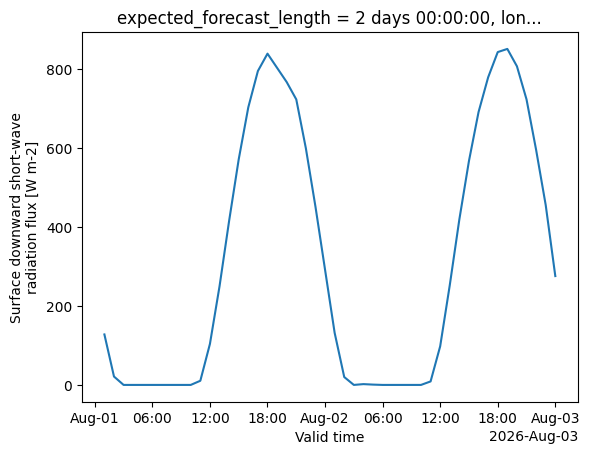

In [2]:
(
    ds["downward_short_wave_radiation_flux_surface"]
    .sel(init_time="2026-08-01T00")
    .sel(x=15, y=0, method="nearest")
    .plot(x="valid_time")
)

Now let's plot temperature at a specific time across the model's whole spatial domain.

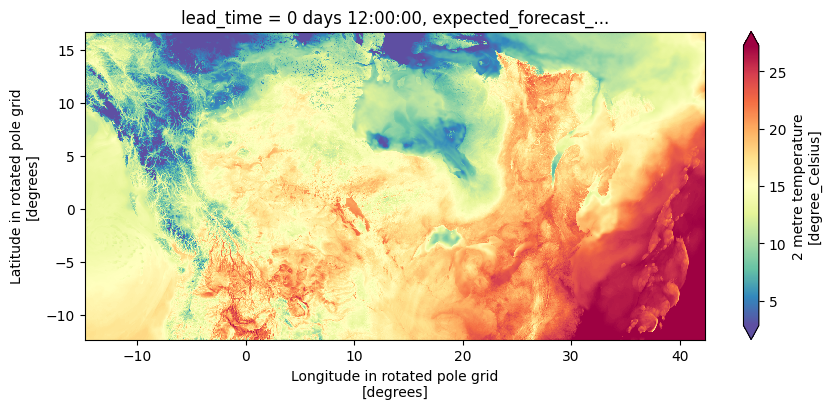

In [3]:
(
    ds["temperature_2m"]
    .sel(init_time="2026-08-01T00", lead_time="12h")
    .plot(figsize=(10, 4), cmap="Spectral_r", robust=True)
)

### How cloudy will Toronto be over the next two days?

To answer this, we need to translate Toronto's latitude, longitude location into the "rotated pole grid" HRDPS uses. We include spatial reference information in the dataset to make this quick and correct.

On August 31st, 2026 the answer was "cloudy for the next day, then clearing up."

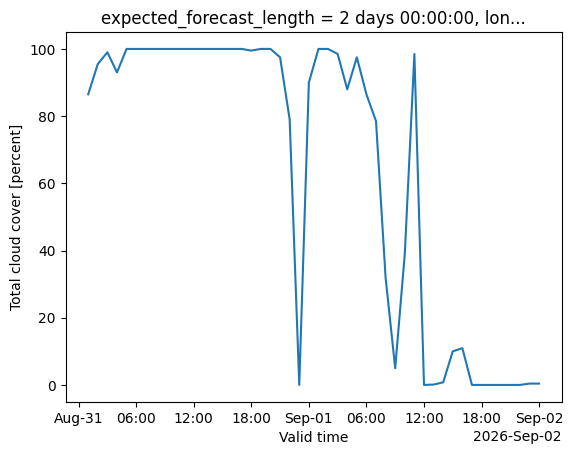

In [4]:
# HRDPS data is distributed in a "rotated pole grid" meaning we need to translate
# the latitude, longitude of a location to look it up in the dataset. We include
# spatial reference information in the dataset to make this quick and correct.

import rioxarray  # for .rio accessor
from pyproj import Transformer

lon_lat_to_ds = Transformer.from_crs("EPSG:4326", ds.rio.crs, always_xy=True)
x, y = lon_lat_to_ds.transform(-79.36, 43.66)  # Toronto, ON

cloud_cover = ds["total_cloud_cover_atmosphere"].sel(init_time="2026-08-31T00", x=x, y=y, method="nearest")
cloud_cover.plot(x="valid_time")

### How do the Great Lakes impact peak wind speeds?

Wind moves faster over the relatively smooth surfaces of the Great Lakes, how much faster exactly? Let's compare average wind speed over a 48 hour forecast covering the region.

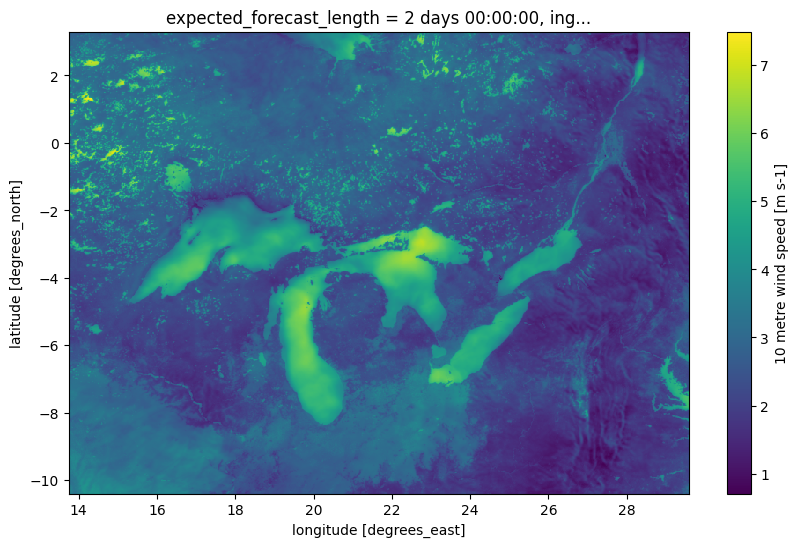

In [5]:
(
    ds["wind_speed_10m"]
    .rio.clip_box(-93, 41, -74, 50, crs="EPSG:4326")
    .sel(init_time="2026-08-08T00")
    .mean(dim="lead_time")
    .plot(figsize=(10, 6))
)

### Community challenge

- **Rank the season's fire-weather windows.** Build a Hot-Dry-Windy index across the domain from
  vapour pressure deficit and wind speed, and find the worst 6-hour windows in the archive. How much
  warning did HRDPS give before significant fire events?
- **Forecast turbine output at hub height.** `wind_speed_80m` is close to modern wind turbine hub
  heights. Convert it to power for the Prairie wind fleet and compare against `wind_speed_10m` with
  a shear assumption. How much does the shortcut cost?
- **Measure how much the model changes its mind.** One valid time is covered by up to eight
  forecasts of different ages. Stack every `init_time` reaching a convective afternoon and quantify
  how the precipitation field converges as lead time shortens.
- **Cross-check against radar.** Compare Q5's accumulation with `noaa-mrms-conus-analysis-hourly`
  where the domains overlap. Does HRDPS put the bands in the right place, or the right amount in the
  wrong place?